In [4]:
import numpy as np
import pandas as pd
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
# 1. Load Clean Dataset
df = pd.read_csv("dwsim_surrogate_clean.csv")
print(f"Loaded {len(df)} clean converged rows.")
# 2. Logit Transform Functions for Purities
def logit_trans(purity, eps=1e-5):
    p_clip = np.clip(purity, eps, 1.0 - eps)
    return np.log(p_clip / (1.0 - p_clip))
def inv_logit_trans(y_logit):
    return 1.0 / (1.0 + np.exp(-y_logit))
# 3. Feature Engineering Function
def engineer_features(df_in):
    X = df_in[["Feed temperature", "Feed pressure", "Feed composition", 
              "Number of stages", "Reflux ratio", "Bottoms withdrawal rate", 
              "Molar flow", "Column pressure", "Feed Stage"]].copy()
    
    F = X["Molar flow"]
    B = X["Bottoms withdrawal rate"]
    xF = X["Feed composition"]
    R = X["Reflux ratio"]
    N = X["Number of stages"]
    NF = X["Feed Stage"]
    
    D = np.maximum(F - B, 1e-5)
    X["D_calc"] = D
    X["mass_balance_ratio"] = (F * xF) / D
    X["L_to_V_ratio"] = (R * D) / ((R + 1.0) * D + 1e-5)
    X["V_to_F_ratio"] = ((R + 1.0) * D) / (F + 1e-5)
    X["NF_fraction"] = NF / N
    
    return X
# Prepare Features
X = engineer_features(df)
# Targets
y_dist = df["Distillate purity"]
y_btm = df["Bottom purity"]
y_cond = df["Condensor Duty"]
y_reb = df["Reboiler Duty"]
# Train/Test Split (80% Train, 20% Test)
indices = np.arange(len(df))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
# -------------------------------------------------------------
# MODEL 1: Distillate Purity (Logit Transformed)
# -------------------------------------------------------------
y_dist_tr_logit = logit_trans(y_dist.iloc[train_idx])
m_dist = ExtraTreesRegressor(n_estimators=300, random_state=42).fit(X_train, y_dist_tr_logit)
pred_dist = inv_logit_trans(m_dist.predict(X_test))
r2_dist = r2_score(y_dist.iloc[test_idx], pred_dist)
# -------------------------------------------------------------
# MODEL 2: Bottom Purity (Logit Transformed)
# -------------------------------------------------------------
y_btm_tr_logit = logit_trans(y_btm.iloc[train_idx])
m_btm = ExtraTreesRegressor(n_estimators=300, random_state=42).fit(X_train, y_btm_tr_logit)
pred_btm = inv_logit_trans(m_btm.predict(X_test))
r2_btm = r2_score(y_btm.iloc[test_idx], pred_btm)
# -------------------------------------------------------------
# MODEL 3: Condenser Duty (Raw Scale)
# -------------------------------------------------------------
m_cond = ExtraTreesRegressor(n_estimators=300, random_state=42).fit(X_train, y_cond.iloc[train_idx])
pred_cond = m_cond.predict(X_test)
r2_cond = r2_score(y_cond.iloc[test_idx], pred_cond)
# -------------------------------------------------------------
# MODEL 4: Reboiler Duty (Raw Scale)
# -------------------------------------------------------------
m_reb = ExtraTreesRegressor(n_estimators=300, random_state=42).fit(X_train, y_reb.iloc[train_idx])
pred_reb = m_reb.predict(X_test)
r2_reb = r2_score(y_reb.iloc[test_idx], pred_reb)
# -------------------------------------------------------------
# PRINT RESULTS SUMMARY
# -------------------------------------------------------------
print("\n================ FINAL SURROGATE MODEL R2 SCORES ================")
print(f"1. Distillate Purity R2: {r2_dist:.4f}  | MAE: {mean_absolute_error(y_dist.iloc[test_idx], pred_dist):.6f}")
print(f"2. Bottom Purity R2:     {r2_btm:.4f}  | MAE: {mean_absolute_error(y_btm.iloc[test_idx], pred_btm):.6f}")
print(f"3. Condenser Duty R2:   {r2_cond:.4f}  | MAE: {mean_absolute_error(y_cond.iloc[test_idx], pred_cond):.4f} kW")
print(f"4. Reboiler Duty R2:    {r2_reb:.4f}  | MAE: {mean_absolute_error(y_reb.iloc[test_idx], pred_reb):.4f} kW")
print("=================================================================")

Loaded 1219 clean converged rows.

================ FINAL SURROGATE MODEL R2 SCORES ================
1. Distillate Purity R2: 0.8484  | MAE: 0.001673
2. Bottom Purity R2:     0.9747  | MAE: 0.003820
3. Condenser Duty R2:   0.9862  | MAE: 2.1754 kW
4. Reboiler Duty R2:    0.9807  | MAE: 3.6155 kW


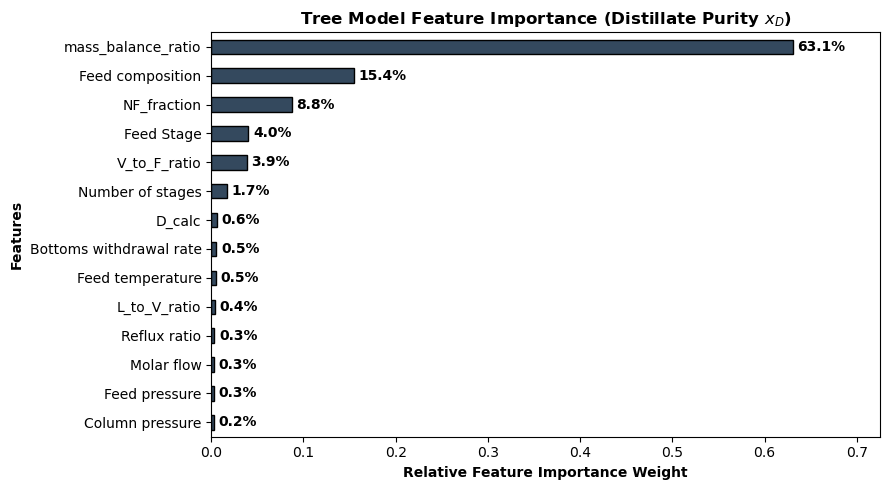

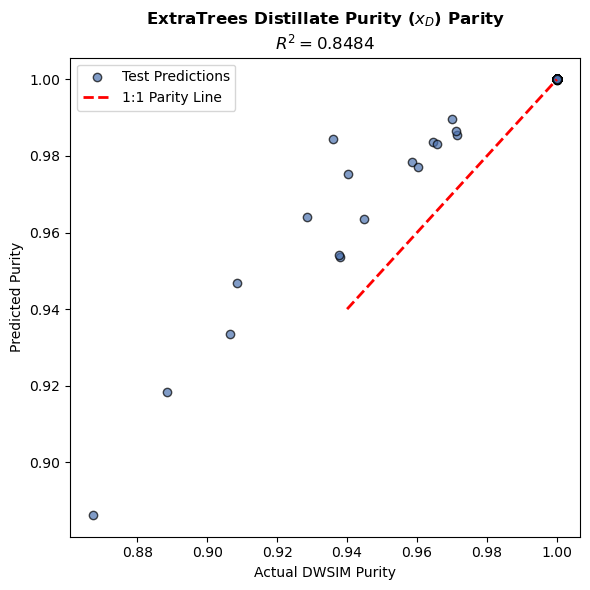

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# --- PLOT 1A: Feature Importance ---
# Extract feature importance for Distillate Purity
importances = pd.Series(m_dist.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
importances.plot(kind='barh', color='#34495e', edgecolor='k')
plt.title('Tree Model Feature Importance (Distillate Purity $x_D$)', fontweight='bold')
plt.xlabel('Relative Feature Importance Weight', fontweight='bold')
plt.ylabel('Features', fontweight='bold')
for i, v in enumerate(importances):
    plt.text(v + 0.005, i, f'{v*100:.1f}%', va='center', fontweight='bold')
plt.xlim([0, max(importances)*1.15])
plt.tight_layout()
plt.savefig("tree_feature_importance.png", dpi=300)
plt.show()

# --- PLOT 1B: Parity Plot ---
plt.figure(figsize=(6, 6))
plt.scatter(y_dist.iloc[test_idx], pred_dist, color='#4c72b0', alpha=0.7, edgecolors='k', label='Test Predictions')
plt.plot([0.94, 1.0], [0.94, 1.0], 'r--', lw=2, label='1:1 Parity Line')
plt.title(f'ExtraTrees Distillate Purity ($x_D$) Parity\n$R^2 = {r2_dist:.4f}$', fontweight='bold')
plt.xlabel('Actual DWSIM Purity')
plt.ylabel('Predicted Purity')
plt.legend()
plt.tight_layout()
plt.savefig("tree_parity_plot.png", dpi=300)
plt.show()